|key|Value|
|---|-----|
|Assignment|Midterm|
|Author|Chris Domingo|
|Date|2024-6-12|



In [7]:
import json

# Demonstration of how to load a file that contains secrets without accidentally leaking those secrets
with open('C:\\Users\\Chris\\Documents\\Bellevue College\\Spring 2024\\DATA 320\\secrets.json') as f:
    data = json.load(f)

    # If you want your data to be secure, don't print this variable out!
    # Jupyter will retain a cached version of any printed data and it can be
    # accidentally committed to version control.
    mongo_connection_string = data['mongodb']

# We can safely print the length of the secret key. That won't leak any sensitive information.
print(f"My secret key is {len(mongo_connection_string)} characters in length.")

My secret key is 69 characters in length.


In [8]:
import pymongo 
import certifi
import pandas
import re

# Connect to the database using known good certificates
client = pymongo.MongoClient(mongo_connection_string, tlsCAFile=certifi.where()) 
db = client.DATABASE320
allCollections = db.list_collection_names()
print(allCollections)

# Find data from IMBD for one particular year using my transformed pipeline view
imbd_view = pandas.DataFrame(db.IMBD_Fixed_Pipeline.find({ "Release_Year": 2008}))

# Find data from Metacritic for the same year
metacritic_view = pandas.DataFrame(db.Metacritic.find({ "release_date": re.compile("2008")}))

# The metacritic view isn't transformed - let's convert valuese to numbers
metacritic_view.score = pandas.to_numeric(metacritic_view.score, errors='coerce')
metacritic_view.release_date = pandas.to_datetime(metacritic_view.release_date, errors='coerce')



['IMBD', 'Metacritic', 'IMBD_Fixed', 'IMBD_Fixed_Pipeline']


In [9]:
# Merge the two datasets together using an inner join - should produce about 175 movies with data on both sides
unified_view = pandas.merge(imbd_view, metacritic_view, how="inner", on="title")
pandas.set_option('display.float_format', '{:.2f}'.format)
unified_view.head()

,_id_x,title,id,Budget_USD,Gross_Sales_USD,Opening_Weekend_USD,Runtime_minutes,User_Rating_num,Votes_num,Release_Year,Release_Month,MPAA_Rating,_id_y,movie_id,release_date,description,score,thumbnail
0,637164223bc31743d94b60da,Let the Right One In,1139797,4000000.00,7282007.00,NaN,114.00,7.90,218259,2008,1,R,662c14ef160251a45c98d81f,14832,2008-10-24,"A fragile, anxious boy, 12-year-old Oskar is r...",82,https://static.metacritic.com/images/products/...
1,6371641c3bc31743d94b60d8,In Bruges,780536,15000000.00,NaN,NaN,107.00,7.90,426119,2008,1,R,662c14ef160251a45c98d879,14922,2008-02-08,Very much out of place amidst the gothic archi...,67,https://static.metacritic.com/images/products/...
2,6371641a3bc31743d94b60d7,The Dark Knight,468569,185000000.00,1004558444.00,158411483.00,152.00,9.00,2633591,2008,7,PG-13,662c14ef160251a45c98d814,14821,2008-07-18,Batman raises the stakes in his war on crime. ...,84,https://static.metacritic.com/images/products/...
3,637164293bc31743d94b60dd,Felon,1117385,2900000.00,NaN,24900.00,104.00,7.40,79550,2008,7,R,662c14ef160251a45c98d8d2,15011,2008-07-18,"A loving family man with a promising future, W...",58,https://static.metacritic.com/images/products/...
4,6371641f3bc31743d94b60d9,Twilight,1099212,37000000.00,392616625.00,69637740.00,122.00,5.30,462755,2008,11,PG-13,662c14ef160251a45c98d8f0,15041,2008-11-21,Bella Swan has always been a little bit differ...,56,https://static.metacritic.com/images/products/...


In [10]:
import numpy
import packaging
import statsmodels.formula.api as smf

# Replace "none" values with NaN
unified_view.replace("none", numpy.nan, inplace=True)

# Drop rows with "none" values 
unified_view_cleaned = unified_view.dropna(subset=['Gross_Sales_USD', 'User_Rating_num', 'Budget_USD', 'Opening_Weekend_USD', 'Votes_num'])
for i in ['Gross_Sales_USD', 'User_Rating_num', 'Budget_USD', 'Opening_Weekend_USD', 'Votes_num']:
    unified_view_cleaned[i] = pandas.to_numeric(unified_view_cleaned[i], errors='coerce')

# Now let's try to plot a linear relationship using all the numeric values we have at the same time
ols_model = smf.ols(
    formula="Gross_Sales_USD ~ User_Rating_num + Budget_USD + Opening_Weekend_USD + Votes_num",
    data=unified_view_cleaned).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:        Gross_Sales_USD   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     105.5
Date:                Wed, 12 Jun 2024   Prob (F-statistic):           2.61e-31
Time:                        14:26:40   Log-Likelihood:                -1681.8
No. Observations:                  86   AIC:                             3374.
Df Residuals:                      81   BIC:                             3386.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -5.663e+07   5

C:\Users\Chris\AppData\Local\Temp\ipykernel_29436\976278124.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unified_view_cleaned[i] = pandas.to_numeric(unified_view_cleaned[i], errors='coerce')


In [28]:
import transformers

# Constructing a pipeline that takes raw text ands pits out an estimate of the text's sentiment
MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
sentiment_task = transformers.pipeline("sentiment-analysis", model=MODEL,
    tokenizer=transformers.AutoTokenizer.from_pretrained(MODEL))

c:\Users\Chris\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [32]:
# Create a function to turn the sentiment analysis object into a single number
def calculate_sentiment(text):
    if text is None:
        return 0
    sentiment = sentiment_task(text)
    if sentiment[0]['label'] == 'negative':
        return 0 - sentiment[0]['score'] - 0.5
    elif sentiment[0]['label'] == 'neutral':
        return sentiment[0]['score'] - 0.5
    elif sentiment[0]['label'] == 'positive':
        return 1 + sentiment[0]['score'] - 0.5
    

In [33]:
# First we will apply a lambda to calculate sentiment for the movies in a dataset
# We use "row.get('description')" instead of "row['description']" because it returns None if there is no description.
sentiment_column = unified_view_cleaned.apply(lambda row: calculate_sentiment(row.get('description')), axis = 1)

# Next add this column back nto the unified view
# Assigning it via an array indexer allows us to re-run this code block multiple times and replace the sentiment column
# so we can tinker with it and update the calculations
unified_view_cleaned["sentiment"] = sentiment_column

# Debugging to see what we have
unified_view_cleaned.head(10)

C:\Users\Chris\AppData\Local\Temp\ipykernel_29436\3851260403.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unified_view_cleaned["sentiment"] = sentiment_column


,_id_x,title,id,Budget_USD,Gross_Sales_USD,Opening_Weekend_USD,Runtime_minutes,User_Rating_num,Votes_num,Release_Year,Release_Month,MPAA_Rating,_id_y,movie_id,release_date,description,score,thumbnail,sentiment
2,6371641a3bc31743d94b60d7,The Dark Knight,468569,185000000.00,1004558444.00,158411483.00,152.00,9.00,2633591,2008,7,PG-13,662c14ef160251a45c98d814,14821,2008-07-18,Batman raises the stakes in his war on crime. ...,84,https://static.metacritic.com/images/products/...,-1.25
4,6371641f3bc31743d94b60d9,Twilight,1099212,37000000.00,392616625.00,69637740.00,122.00,5.30,462755,2008,11,PG-13,662c14ef160251a45c98d8f0,15041,2008-11-21,Bella Swan has always been a little bit differ...,56,https://static.metacritic.com/images/products/...,-0.95
6,6371643a3bc31743d94b60e3,Tropic Thunder,942385,92000000.00,188072649.00,25812796.00,107.00,7.00,416319,2008,8,R,662c14ef160251a45c98d857,14888,2008-08-13,Tropic Thunder is an action comedy about a gro...,71,https://static.metacritic.com/images/products/...,-1.23
7,637164b03bc31743d94b610e,Hancock,448157,150000000.00,624386746.00,62603879.00,92.00,6.40,482849,2008,6,R,662c14ef160251a45c98d92e,15103,2008-07-02,There are heroes… there are superheroes… and t...,49,https://static.metacritic.com/images/products/...,-1.01
8,6371643d3bc31743d94b60e4,Step Brothers,838283,65000000.00,128107642.00,30940732.00,98.00,6.90,296207,2008,7,R,662c14ef160251a45c98d926,15095,2008-07-25,Brennan Huff is a sporadically employed thirty...,51,https://static.metacritic.com/images/products/...,-1.23
10,637164a53bc31743d94b610a,The Day the Earth Stood Still,970416,80000000.00,233093859.00,30480153.00,104.00,5.50,171532,2008,12,PG-13,662c14ef160251a45c98d965,15158,2008-12-12,The Day the Earth Stood Still is 20th Century ...,40,https://static.metacritic.com/images/products/...,-0.07
12,637164c63bc31743d94b6116,Prom Night,926129,20000000.00,57197876.00,20804941.00,88.00,3.90,36298,2008,4,PG-13,662c14ef160251a45c98d9ab,15228,2008-04-11,Donna's senior prom is supposed to be the best...,17,https://static.metacritic.com/images/products/...,-1.08
13,637164573bc31743d94b60ed,Kung Fu Panda,441773,130000000.00,631744560.00,60239130.00,92.00,7.60,469445,2008,5,PG,662c14ef160251a45c98d845,14870,2008-06-06,"Enthusiastic, big and a little clumsy, Po is t...",74,https://static.metacritic.com/images/products/...,-0.90
14,637164543bc31743d94b60ec,21,478087,35000000.00,157927340.00,24105943.00,123.00,6.80,252827,2008,3,PG-13,662c14ef160251a45c98d937,15112,2008-03-28,"Ben Campbell is a shy, brilliant MIT student w...",48,https://static.metacritic.com/images/products/...,-1.02
15,6371647f3bc31743d94b60fc,The Mummy: Tomb of the Dragon Emperor,859163,145000000.00,401128639.00,40457770.00,112.00,5.20,161901,2008,7,PG-13,662c14ef160251a45c98d991,15202,2008-08-01,Explorer Rick O'Connell is back to combat the ...,31,https://static.metacritic.com/images/products/...,-1.10


Text(0, 0.5, 'Sentiment')

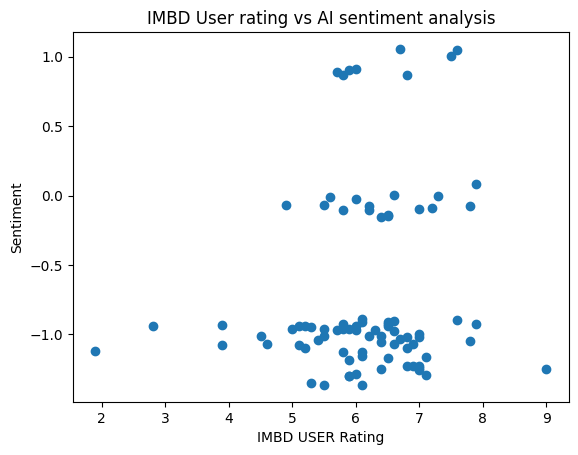

In [34]:
from matplotlib import pyplot 

# Compare sentiment of movies against user rating
pyplot.scatter(unified_view_cleaned['User_Rating_num'], unified_view_cleaned['sentiment'])
pyplot.title("IMBD User rating vs AI sentiment analysis")
pyplot.xlabel('IMBD USER Rating')
pyplot.ylabel('Sentiment')

In [51]:
# A custom formatter for currency
from numbers import Number

def format_currency(amount: Number, _):
    if amount > 1_000_000_000_000:
        return f"${round(amount / 1_000_000_000_000)}T"
    elif amount > 1_000_000_000:
        return f"${round(amount / 1_000_000_000)}B"
    elif amount > 1_000_000:
        return f"${round(amount / 1_000_000)}M"
    elif amount > 1_000:
        return f"${round(amount / 1_000)}K"
    else:
        return f"${round(amount)}"

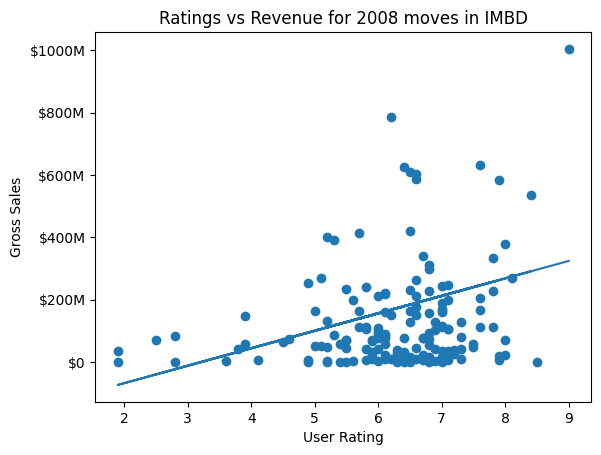

In [63]:
# Filter to a specific year
selected_films = imbd_view[imbd_view['Release_Year'] == 2008]

# Plot release date by runtime
pyplot.title('Ratings vs Revenue for 2008 moves in IMBD')
pyplot.scatter(selected_films['User_Rating_num'], selected_films['Gross_Sales_USD'])
pyplot.xlabel('User Rating')
pyplot.ylabel('Gross Sales')
pyplot.gca().yaxis.set_major_formatter(format_currency)

# Add a trend line to the ratings vs revenue chart
imbd_only_real_values = selected_films.dropna()
trend = numpy.polyfit(imbd_only_real_values['User_Rating_num'], imbd_only_real_values['Gross_Sales_USD'], 1)
prediction_function = numpy.poly1d(trend)
pyplot.plot(imbd_only_real_values['User_Rating_num'], prediction_function(imbd_only_real_values['User_Rating_num']))

# Show the final chart
pyplot.show()

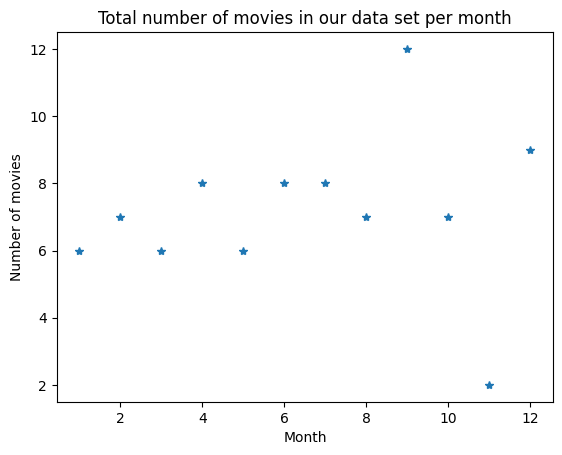

In [35]:
# Group by month
monthly_view = unified_view_cleaned['Release_Month'].groupby(unified_view_cleaned.Release_Month).agg('count')

# Let's compare sentiment of movies against user rating
pyplot.title("Total number of movies in our data set per month")
pyplot.xlabel("Month")
pyplot.ylabel("Number of movies")
pyplot.plot(monthly_view, '*')
pyplot.show()

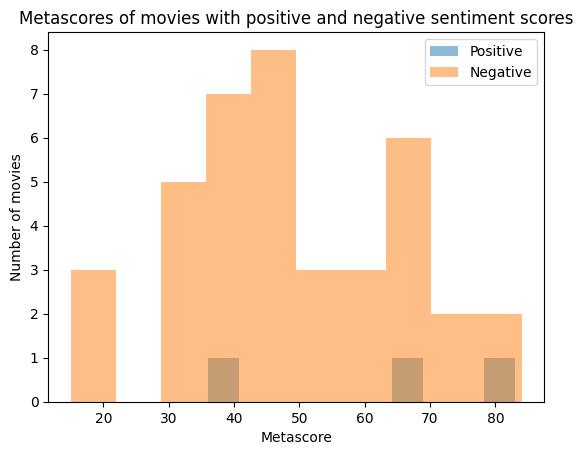

In [48]:
happy_movies = unified_view_cleaned[unified_view_cleaned['sentiment'] > 1].score
sad_movies = unified_view_cleaned[unified_view_cleaned['sentiment'] < -1].score

# What about budget - do happy movies score better than sad ones?
pyplot.title("Metascores of movies with positive and negative sentiment scores")
pyplot.xlabel("Metascore")
pyplot.ylabel("Number of movies")
pyplot.hist(happy_movies, alpha=0.5, label="Positive")
pyplot.hist(sad_movies, alpha=0.5, label="Negative")
pyplot.legend(loc="upper right")
pyplot.show()


In [46]:
# This model will now use sentiment, user rating, and the combination of the two
ols_model = smf.ols(
    formula="Gross_Sales_USD ~ Budget_USD + Opening_Weekend_USD + Votes_num + sentiment * User_Rating_num",
    data=unified_view_cleaned).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Gross_Sales_USD   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     72.05
Date:                Wed, 12 Jun 2024   Prob (F-statistic):           5.56e-30
Time:                        16:09:45   Log-Likelihood:                -1680.0
No. Observations:                  86   AIC:                             3374.
Df Residuals:                      79   BIC:                             3391.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import io
import requests

df_url = 'https://raw.githubusercontent.com/akmand/datasets/master/openintro/kobe.csv'
url_content = requests.get(df_url, verify=False).content
kobe = pd.read_csv(io.StringIO(url_content.decode('utf-8')))

kobe.head()

<h1>Conclusions:<h1>

<h3>
Here's what I learned from the data:
<ul>
<li>When I added in the sentiment values to the model, it made the R-squared a little better, but not by much
<li>For the user ratings, most movies was in the range of 5-8 and the majority of them had a negative sentiment value.
<li>For movies in 2008, the gross sales of movies went up as the user rating went up as well.  So there's a positive relationship there.
<li>The most number of movies that got released in 2008 as well happened in the month of September, with 12 releasing that month.  The lowest number that got released 
as well was during November with 2 movies.  The most movies that got constantly released was during the summer season as well, since between June-August, around 7-8 movies
got released during each of those months.
<li>There seems to be more movies with negative sentiment scores as well rather than positive sentiment scores.  There's only three movies total that got positive sentiment scores.
</ul>
</h3>